In [1]:
from torch.utils.data import DataLoader
import time

import torch
import pytorch_lightning as pl
import numpy as np
import pandas as pd

from mock_dataset import MockDataset
from models import SimpleLinearModel, SCVI

torch.set_float32_matmul_precision("high")

In [2]:
INPUT_DIM = 20000
N_CLASSES = 100
N_SAMPLES_PER_EPOCH = 2**17


def create_loader(batch_size):
    assert (N_SAMPLES_PER_EPOCH % batch_size) == 0
    
    return DataLoader(
        MockDataset(
            batch_size,
            0.5,
            INPUT_DIM,
            N_CLASSES,
            N_SAMPLES_PER_EPOCH // batch_size,
        ),
        batch_size=None,
    )


def train_model(model):
    res = {"batch_size": [], "fit_time": []}

    for batch_size in np.logspace(8, 16, base=2, num=9, dtype="i8"):
        trainer = pl.Trainer(
            max_epochs=1,
            logger=False,
            enable_model_summary=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
        )
        start = time.time()
        trainer.fit(model, train_dataloaders=create_loader(batch_size))
        res["fit_time"].append(time.time() - start)
        res["batch_size"].append(batch_size)

    return pd.DataFrame(res)


In [3]:
res = train_model(
    SCVI(
        input_dim=INPUT_DIM,
        hidden_dims=[256, 256],
        latent_dim=50,
        lr=1e-3,
        weight_decay=1e-6,
        beta=1.0,
        dropout=0.,
    )
)

/vol/data/miniconda3/envs/annbatch/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/vol/data/miniconda3/envs/annbatch/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


In [4]:
res

,batch_size,fit_time
0,256,263.117010
1,512,132.434669
2,1024,66.791550
3,2048,34.055916
4,4096,17.596677
5,8192,9.237130
6,16384,5.150969
7,32768,3.234217
8,65536,2.540616


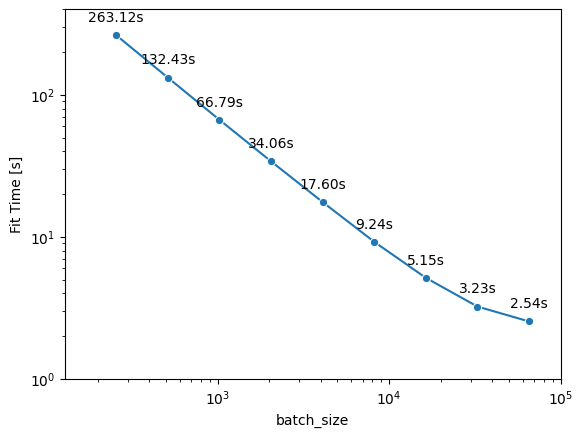

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.lineplot(res, x="batch_size", y="fit_time", marker="o")
ax.set_ylabel("Fit Time [s]")
ax.set_xlabel("batch_size")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlim(128, 100000)
ax.set_ylim(1, 400)

for i, row in res.iterrows():
    ax.annotate(f'{row["fit_time"]:.2f}s', 
                (row["batch_size"], row["fit_time"]),
                textcoords="offset points", 
                xytext=(0,10),
                ha='center')

plt.savefig("fit_time_vs_batch_size.png", dpi=300, bbox_inches='tight')
plt.savefig("fit_time_vs_batch_size.svg", dpi=300, bbox_inches='tight')

In [8]:
res.to_csv("fit_time_vs_batch_size.csv")